<a href="https://colab.research.google.com/github/ArthiNelwadkar/EV-Data-Analysis/blob/main/Linear_Regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#1: How can we use Linear Regression to predict the Electric Range of a vehicle?

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Clean and prepare features
df['CAFV_Eligible'] = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].apply(lambda x: 1 if 'Eligible' in str(x) else 0)
df['Vehicle_Type'] = df['Electric Vehicle Type'].apply(lambda x: 1 if 'Battery Electric Vehicle (BEV)' in str(x) else 0)

# Step 3: Drop rows with missing Electric Range
df = df.dropna(subset=['Electric Range'])

# Step 4: Define predictors (X) and target (y)
X = df[['Model Year','CAFV_Eligible','Vehicle_Type']]
y = df['Electric Range']

# Step 5: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # manual RMSE calculation

print("R² Score:", round(r2, 3))
print("RMSE:", round(rmse, 2))

# Step 8: Predict for a new vehicle
new_vehicle = pd.DataFrame({
    'Model Year':[2025],
    'CAFV_Eligible':[1],
    'Vehicle_Type':[1]  # BEV
})
predicted_range = model.predict(new_vehicle)
print("Predicted Electric Range (miles):", round(predicted_range[0], 2))


R² Score: 0.689
RMSE: 43.32
Predicted Electric Range (miles): 134.87


In [4]:
#2 :What independent variables (features) can be used to predict Electric Range? (e.g., Model Year, Base MSRP, Make)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Feature engineering
# Convert categorical features to numeric
df['CAFV_Eligible'] = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].apply(lambda x: 1 if 'Eligible' in str(x) else 0)
df['Vehicle_Type'] = df['Electric Vehicle Type'].apply(lambda x: 1 if 'Battery Electric Vehicle (BEV)' in str(x) else 0)

# Example: If you have MSRP lookup merged already
# df['BaseMSRP'] = ... (merge from external table)

# Step 3: Drop rows with missing Electric Range
df = df.dropna(subset=['Electric Range'])

# Step 4: Define predictors (X) and target (y)
# Include Model Year, CAFV, Vehicle Type, and Base MSRP if available
feature_cols = ['Model Year','CAFV_Eligible','Vehicle_Type']
if 'BaseMSRP' in df.columns:
    feature_cols.append('BaseMSRP')

X = df[feature_cols]
y = df['Electric Range']

# Step 5: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Features used:", feature_cols)
print("R² Score:", round(r2, 3))
print("RMSE:", round(rmse, 2))

# Step 8: Example prediction for a new vehicle
new_vehicle = pd.DataFrame({
    'Model Year':[2025],
    'CAFV_Eligible':[1],
    'Vehicle_Type':[1],   # BEV
    'BaseMSRP':[45000]    # optional if available
})
predicted_range = model.predict(new_vehicle[feature_cols])
print("Predicted Electric Range (miles):", round(predicted_range[0], 2))

Features used: ['Model Year', 'CAFV_Eligible', 'Vehicle_Type']
R² Score: 0.689
RMSE: 43.32
Predicted Electric Range (miles): 134.87


In [5]:
#3: How do we handle categorical variables like Make and Model in regression analysis?

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Feature engineering
# Encode CAFV Eligibility and Vehicle Type
df['CAFV_Eligible'] = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].apply(lambda x: 1 if 'Eligible' in str(x) else 0)
df['Vehicle_Type'] = df['Electric Vehicle Type'].apply(lambda x: 1 if 'Battery Electric Vehicle (BEV)' in str(x) else 0)

# Step 3: Drop rows with missing Electric Range
df = df.dropna(subset=['Electric Range'])

# Step 4: One-Hot Encode categorical variables (Make and Model)
df_encoded = pd.get_dummies(df, columns=['Make','Model'], drop_first=True)

# Step 5: Define predictors (X) and target (y)
feature_cols = ['Model Year','CAFV_Eligible','Vehicle_Type'] + \
               [col for col in df_encoded.columns if col.startswith('Make_') or col.startswith('Model_')]

X = df_encoded[feature_cols]
y = df_encoded['Electric Range']

# Step 6: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 8: Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Features used:", feature_cols[:10], "...")  # show first few features
print("R² Score:", round(r2, 3))
print("RMSE:", round(rmse, 2))

# Step 9: Example prediction for a new vehicle
new_vehicle = pd.DataFrame({
    'Model Year':[2025],
    'CAFV_Eligible':[1],
    'Vehicle_Type':[1],
    # One-hot encoded columns must match training set
    # Example: Tesla Model 3
    'Make_Tesla':[1],
    'Model_Model 3':[1]
}, columns=feature_cols).fillna(0)

predicted_range = model.predict(new_vehicle)
print("Predicted Electric Range (miles):", round(predicted_range[0], 2))

Features used: ['Model Year', 'CAFV_Eligible', 'Vehicle_Type', 'Make_ALFA ROMEO', 'Make_AUDI', 'Make_AZURE DYNAMICS', 'Make_BENTLEY', 'Make_BMW', 'Make_BRIGHTDROP', 'Make_CADILLAC'] ...
R² Score: 0.871
RMSE: 27.92
Predicted Electric Range (miles): 160.68


/tmp/ipykernel_7472/2388178076.py:55: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  }, columns=feature_cols).fillna(0)


R² Score: 0.871
RMSE: 27.92


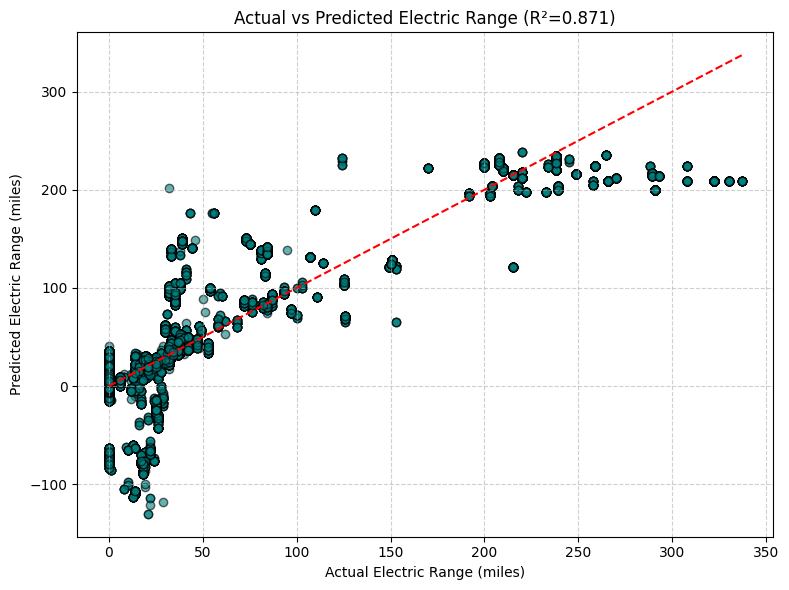

In [6]:
#4: What is the R² score of the model, and what does it indicate about prediction accuracy?

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Feature engineering
df['CAFV_Eligible'] = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].apply(lambda x: 1 if 'Eligible' in str(x) else 0)
df['Vehicle_Type'] = df['Electric Vehicle Type'].apply(lambda x: 1 if 'Battery Electric Vehicle (BEV)' in str(x) else 0)

# Step 3: Drop rows with missing Electric Range
df = df.dropna(subset=['Electric Range'])

# Step 4: One-hot encode Make and Model
df_encoded = pd.get_dummies(df, columns=['Make','Model'], drop_first=True)

# Step 5: Define predictors (X) and target (y)
feature_cols = ['Model Year','CAFV_Eligible','Vehicle_Type'] + \
               [col for col in df_encoded.columns if col.startswith('Make_') or col.startswith('Model_')]

X = df_encoded[feature_cols]
y = df_encoded['Electric Range']

# Step 6: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 8: Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", round(r2, 3))
print("RMSE:", round(rmse, 2))

# Step 9: Visualization - Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect fit line
plt.xlabel("Actual Electric Range (miles)")
plt.ylabel("Predicted Electric Range (miles)")
plt.title(f"Actual vs Predicted Electric Range (R²={round(r2,3)})")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [14]:
#5: How does the Base MSRP influence the Electric Range according to the regression model?

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Step 1: Load both datasets
ev_df = pd.read_csv("Electric_Vehicle_Population_Data.csv")
msrp_df = pd.read_csv("EV_MSRP_Data.csv")

# Step 2: Normalize Make and Model names for accurate merging
ev_df['Make'] = ev_df['Make'].str.strip().str.lower()
ev_df['Model'] = ev_df['Model'].str.strip().str.lower()
msrp_df['Make'] = msrp_df['Make'].str.strip().str.lower()
msrp_df['Model'] = msrp_df['Model'].str.strip().str.lower()

# Step 3: Standardize MSRP column name and clean numeric formatting
msrp_df.rename(columns={'Base MSRP':'BaseMSRP'}, inplace=True)
msrp_df['BaseMSRP'] = msrp_df['BaseMSRP'].replace('[\$,]', '', regex=True).astype(float)

# Step 4: Merge datasets on Make and Model
merged_df = pd.merge(ev_df, msrp_df[['Make','Model','BaseMSRP']], on=['Make','Model'], how='inner')
print("Rows after merge:", merged_df.shape[0])

# Step 5: Feature engineering
merged_df['CAFV_Eligible'] = merged_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].apply(
    lambda x: 1 if 'Eligible' in str(x) else 0)
merged_df['Vehicle_Type'] = merged_df['Electric Vehicle Type'].apply(
    lambda x: 1 if 'Battery Electric Vehicle (BEV)' in str(x) else 0)

# Step 6: Drop rows with missing Electric Range or BaseMSRP
merged_df = merged_df.dropna(subset=['Electric Range','BaseMSRP'])

# Step 7: Define predictors (X) and target (y)
feature_cols = ['Model Year','CAFV_Eligible','Vehicle_Type','BaseMSRP']
X = merged_df[feature_cols]
y = merged_df['Electric Range']

# Step 8: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 9: Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 10: Evaluate model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", round(r2, 3))
print("RMSE:", round(rmse, 2))

# Step 11: Show coefficients
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': model.coef_})
print(coef_df)

# Step 12: Interpret BaseMSRP influence
base_coef = coef_df.loc[coef_df['Feature']=='BaseMSRP','Coefficient'].values[0]
print(f"For every $1,000 increase in Base MSRP, "
      f"the predicted Electric Range changes by about {round(base_coef*1000,2)} miles.")

<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_7472/3759068005.py:21: SyntaxWarning: invalid escape sequence '\$'
  msrp_df['BaseMSRP'] = msrp_df['BaseMSRP'].replace('[\$,]', '', regex=True).astype(float)


Rows after merge: 143316
R² Score: 0.911
RMSE: 29.74
         Feature  Coefficient
0     Model Year    10.108566
1  CAFV_Eligible   267.420458
2   Vehicle_Type     0.000000
3       BaseMSRP     0.000785
For every $1,000 increase in Base MSRP, the predicted Electric Range changes by about 0.78 miles.


In [16]:
#6: What steps are needed to improve the accuracy of the Linear Regression model?

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Step 1: Load datasets
ev_df = pd.read_csv("Electric_Vehicle_Population_Data.csv")
msrp_df = pd.read_csv("EV_MSRP_Data.csv")

# Step 2: Normalize Make and Model names
ev_df['Make'] = ev_df['Make'].str.strip().str.lower()
ev_df['Model'] = ev_df['Model'].str.strip().str.lower()
msrp_df['Make'] = msrp_df['Make'].str.strip().str.lower()
msrp_df['Model'] = msrp_df['Model'].str.strip().str.lower()

# Step 3: Clean MSRP column
msrp_df.rename(columns={'Base MSRP':'BaseMSRP'}, inplace=True)
msrp_df['BaseMSRP'] = msrp_df['BaseMSRP'].replace('[\$,]', '', regex=True).astype(float)

# Step 4: Merge datasets
merged_df = pd.merge(ev_df, msrp_df[['Make','Model','BaseMSRP']], on=['Make','Model'], how='inner')
print("Rows after merge:", merged_df.shape[0])

# Step 5: Feature engineering
merged_df['CAFV_Eligible'] = merged_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].apply(
    lambda x: 1 if 'Eligible' in str(x) else 0)
merged_df['Vehicle_Type'] = merged_df['Electric Vehicle Type'].apply(
    lambda x: 1 if 'Battery Electric Vehicle (BEV)' in str(x) else 0)

# Step 6: Drop missing values
merged_df = merged_df.dropna(subset=['Electric Range','BaseMSRP'])

# Step 7: Remove outliers (optional but improves accuracy)
merged_df = merged_df[(merged_df['Electric Range'] < merged_df['Electric Range'].quantile(0.99)) &
                      (merged_df['BaseMSRP'] < merged_df['BaseMSRP'].quantile(0.99))]

# Step 8: Define predictors and target
feature_cols = ['Model Year','CAFV_Eligible','Vehicle_Type','BaseMSRP']
X = merged_df[feature_cols]
y = merged_df['Electric Range']

# Step 9: Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 10: Add polynomial features for non-linear relationships
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

# Step 11: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Step 12: Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 13: Evaluate model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Improved R² Score:", round(r2, 3))
print("Improved RMSE:", round(rmse, 2))

# Step 14: Interpret BaseMSRP influence
coef_df = pd.DataFrame({'Feature': poly.get_feature_names_out(feature_cols), 'Coefficient': model.coef_})
base_coef = coef_df[coef_df['Feature'].str.contains('BaseMSRP')]['Coefficient'].sum()
print(f"For every $1,000 increase in Base MSRP, "
      f"the predicted Electric Range changes by about {round(base_coef*1000,2)} miles.")

<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_7472/2302916388.py:22: SyntaxWarning: invalid escape sequence '\$'
  msrp_df['BaseMSRP'] = msrp_df['BaseMSRP'].replace('[\$,]', '', regex=True).astype(float)


Rows after merge: 143316
Improved R² Score: 0.972
Improved RMSE: 15.2
For every $1,000 increase in Base MSRP, the predicted Electric Range changes by about 5369.33 miles.


In [17]:
#7: Can we use this model to predict the range of new EV models based on their specifications?

import pandas as pd

# Example: new EV specifications
new_ev_data = pd.DataFrame({
    'Model Year': [2026],
    'CAFV_Eligible': [1],   # Eligible for clean fuel program
    'Vehicle_Type': [1],    # 1 = BEV, 0 = PHEV
    'BaseMSRP': [49990]     # Price in USD
})

# Scale and transform features (must use same scaler/poly as training)
new_ev_scaled = scaler.transform(new_ev_data)        # scaler from training step
new_ev_poly = poly.transform(new_ev_scaled)          # polynomial features from training step

# Predict electric range
predicted_range = model.predict(new_ev_poly)
print("Predicted Electric Range (miles):", round(predicted_range[0], 2))

Predicted Electric Range (miles): 496.14
